#### 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import sys
sys.path.append('../src')
from data_loader import EconomyDataLoader

# Sets a global visual theme for plots
sns.set_style("whitegrid")
# Sets the default figure size for all plots
plt.rcParams['figure.figsize'] = (14, 6)
# Tells Jupyter to render plots directly inside the notebook output cell
%matplotlib inline
# Sets the output resolution of inline plots
%config InlineBackend.figure_format = 'retina'

#### 2. Load Raw Data

In [2]:
loader = EconomyDataLoader(economy='eurozone')

# build_raw_dataset originally retrieves data that goes 5y before the start_date so that the dataset after feature engineering would
# start more or less at the start_date
start_date = '2000-01-01'
df_raw_offset = loader.build_raw_dataset(start_date = start_date)

n = 0
while True:
    try:
        df_raw = df_raw_offset.iloc[df_raw_offset[df_raw_offset['date'] == (pd.to_datetime(start_date) + timedelta(days = n))].index[0]:]
        break
    except:
        n += 1

print(f"Dataset shape: {df_raw.shape}")
print(f"Date range: {datetime.strftime(df_raw['date'].min(), '%Y-%m-%d')} to {datetime.strftime(df_raw['date'].max(), '%Y-%m-%d')}")
df_raw.head()

Dataset shape: (5650, 14)
Date range: 2004-04-26 to 2025-12-23


,date,interbank_3m,Real_GDP,Consumer_Confidence(%balance),Real_Property_Prices_YoY,HICP,yield_10y,ECB_Assets,ECB_Deposit_Rate,Gold,STOXX600,EURUSD,Crude_Oil,Natural_Gas
0,2004-04-26,2.04875,2258094.6,-12.6,4.0718,82.71,4.242426,842718.0,1.0,396.000000,247.070007,1.186197,36.970001,5.764
1,2004-04-27,2.04875,2258094.6,-12.6,4.0718,82.71,4.242426,842718.0,1.0,398.600006,246.919998,1.192905,37.529999,5.874
2,2004-04-28,2.04875,2258094.6,-12.6,4.0718,82.71,4.242426,842718.0,1.0,385.399994,243.380005,1.184301,37.459999,5.935
3,2004-04-29,2.04875,2258094.6,-12.6,4.0718,82.71,4.242426,842718.0,1.0,386.600006,241.250000,1.196001,37.310001,5.924
4,2004-04-30,2.04875,2258094.6,-12.6,4.0718,82.71,4.242426,853538.0,1.0,387.000000,239.050003,1.198294,37.380001,5.862


#### 3. Data Quality Assessment

In [3]:
print("General Overview")
print(df_raw.info())

print("\nBasic Statistics:")
df_raw.describe().T

General Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5650 entries, 0 to 5649
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           5650 non-null   datetime64[ns]
 1   interbank_3m                   5650 non-null   float64       
 2   Real_GDP                       5650 non-null   float64       
 3   Consumer_Confidence(%balance)  5650 non-null   float64       
 4   Real_Property_Prices_YoY       5650 non-null   float64       
 5   HICP                           5650 non-null   float64       
 6   yield_10y                      5650 non-null   float64       
 7   ECB_Assets                     5650 non-null   float64       
 8   ECB_Deposit_Rate               5650 non-null   float64       
 9   Gold                           5650 non-null   float64       
 10  STOXX600                       5650 non-null   float64       
 11  

,count,mean,min,25%,50%,75%,max,std
date,5650,2015-02-21 14:33:56.389380608,2004-04-26 00:00:00,2009-09-23 06:00:00,2015-02-21 12:00:00,2020-07-21 18:00:00,2025-12-23 00:00:00,NaN
interbank_3m,5650.0,1.259425,-0.581957,-0.308,0.712045,2.344864,5.113087,1.66322
Real_GDP,5650.0,2544896.649929,2258094.6,2414733.2,2483950.8,2694284.5,2879256.8,177415.27681
Consumer_Confidence(%balance),5650.0,-12.492602,-28.8,-16.0,-12.5,-7.9,-2.1,5.36881
Real_Property_Prices_YoY,5650.0,0.911974,-7.2964,-2.1517,2.4678,3.8792,6.231,3.536639
HICP,5650.0,101.583775,82.71,91.99,100.03,105.31,129.71,12.45586
yield_10y,5650.0,2.596297,-0.091882,1.202421,3.087957,3.868687,4.814509,1.427933
ECB_Assets,5650.0,3709663.290982,842046.0,1875712.0,2794527.0,6082009.0,8835987.0,2398779.111213
ECB_Deposit_Rate,5650.0,0.788274,-0.5,-0.4,0.25,2.0,4.0,1.390753
Gold,5650.0,1402.145061,374.799988,1004.925018,1296.649963,1742.024963,4482.799805,663.944859


#### 4. (Potential) Target Variable Analysis

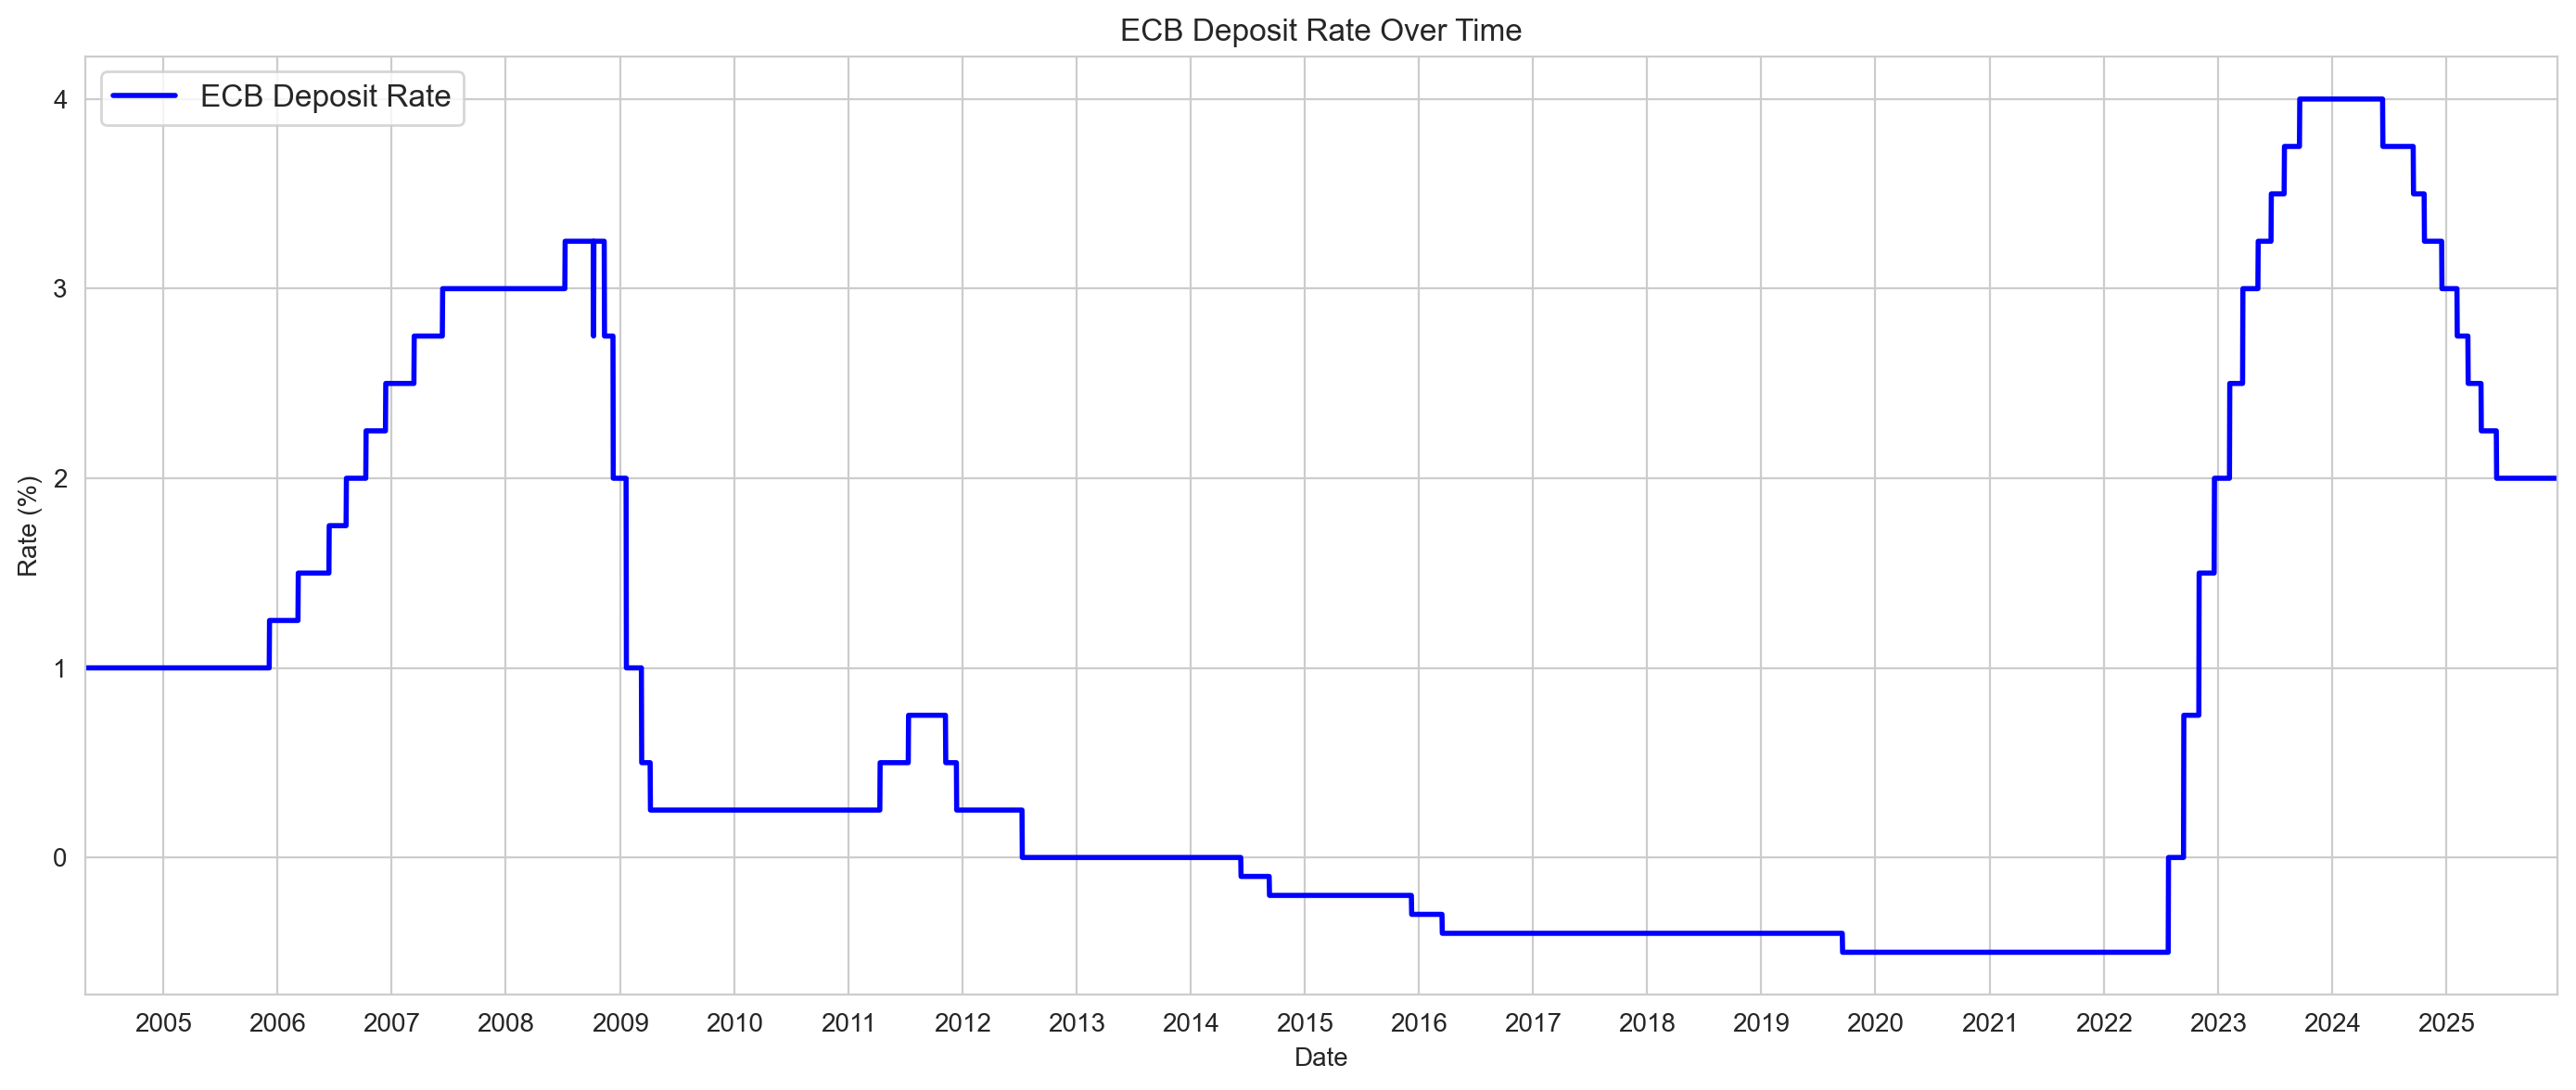

In [4]:
sns.lineplot(
    data=df_raw,
    x='date',
    y='ECB_Deposit_Rate',
    linewidth=2,
    color='blue',
    label='ECB Deposit Rate'
)

plt.title('ECB Deposit Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate (%)')
plt.legend(fontsize = 12)
plt.xlim(df_raw['date'].min(), df_raw['date'].max())
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=25))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### 5. Distribution Analysis

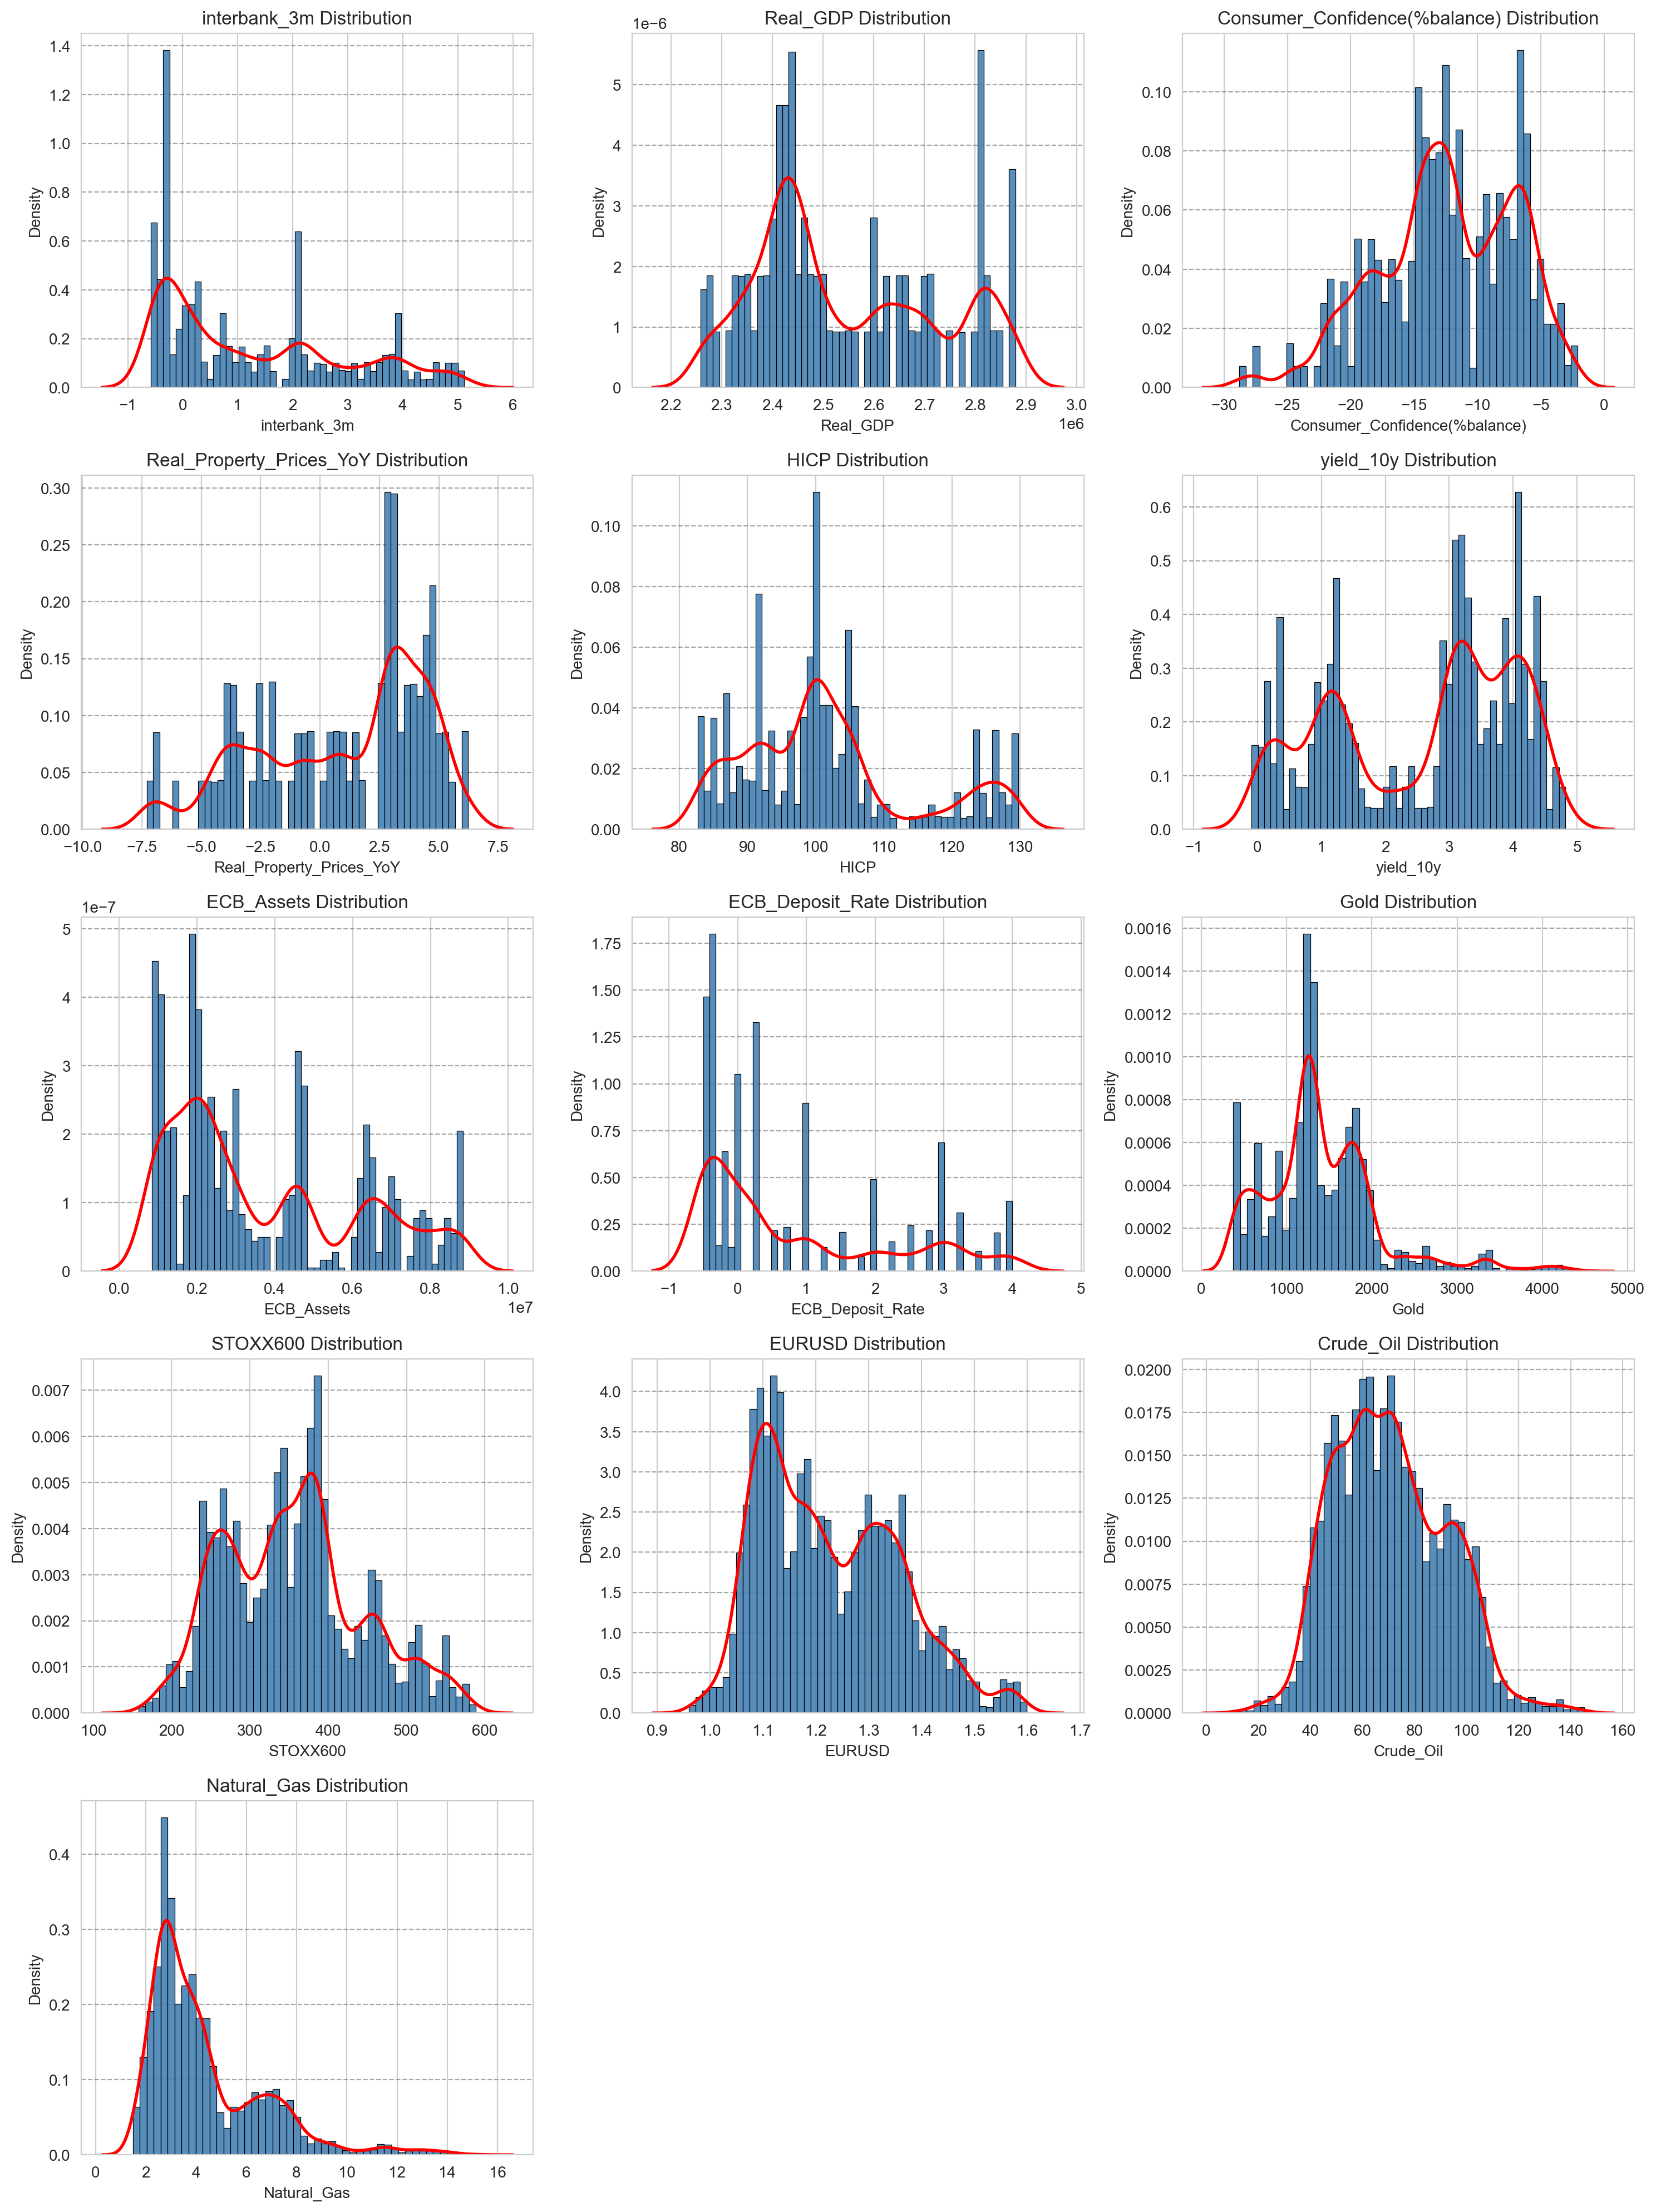

In [5]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
cols_number = 3
rows = int(np.ceil(len(numeric_cols)/cols_number))

fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    sns.histplot(data = df_raw[col], bins = 50, ax = axes[i], edgecolor = 'black', alpha = 0.9, color = 'steelblue', stat = 'density')
    sns.kdeplot(data = df_raw[col], color = 'red', ax = axes[i], linewidth = 2)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{col} Distribution')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

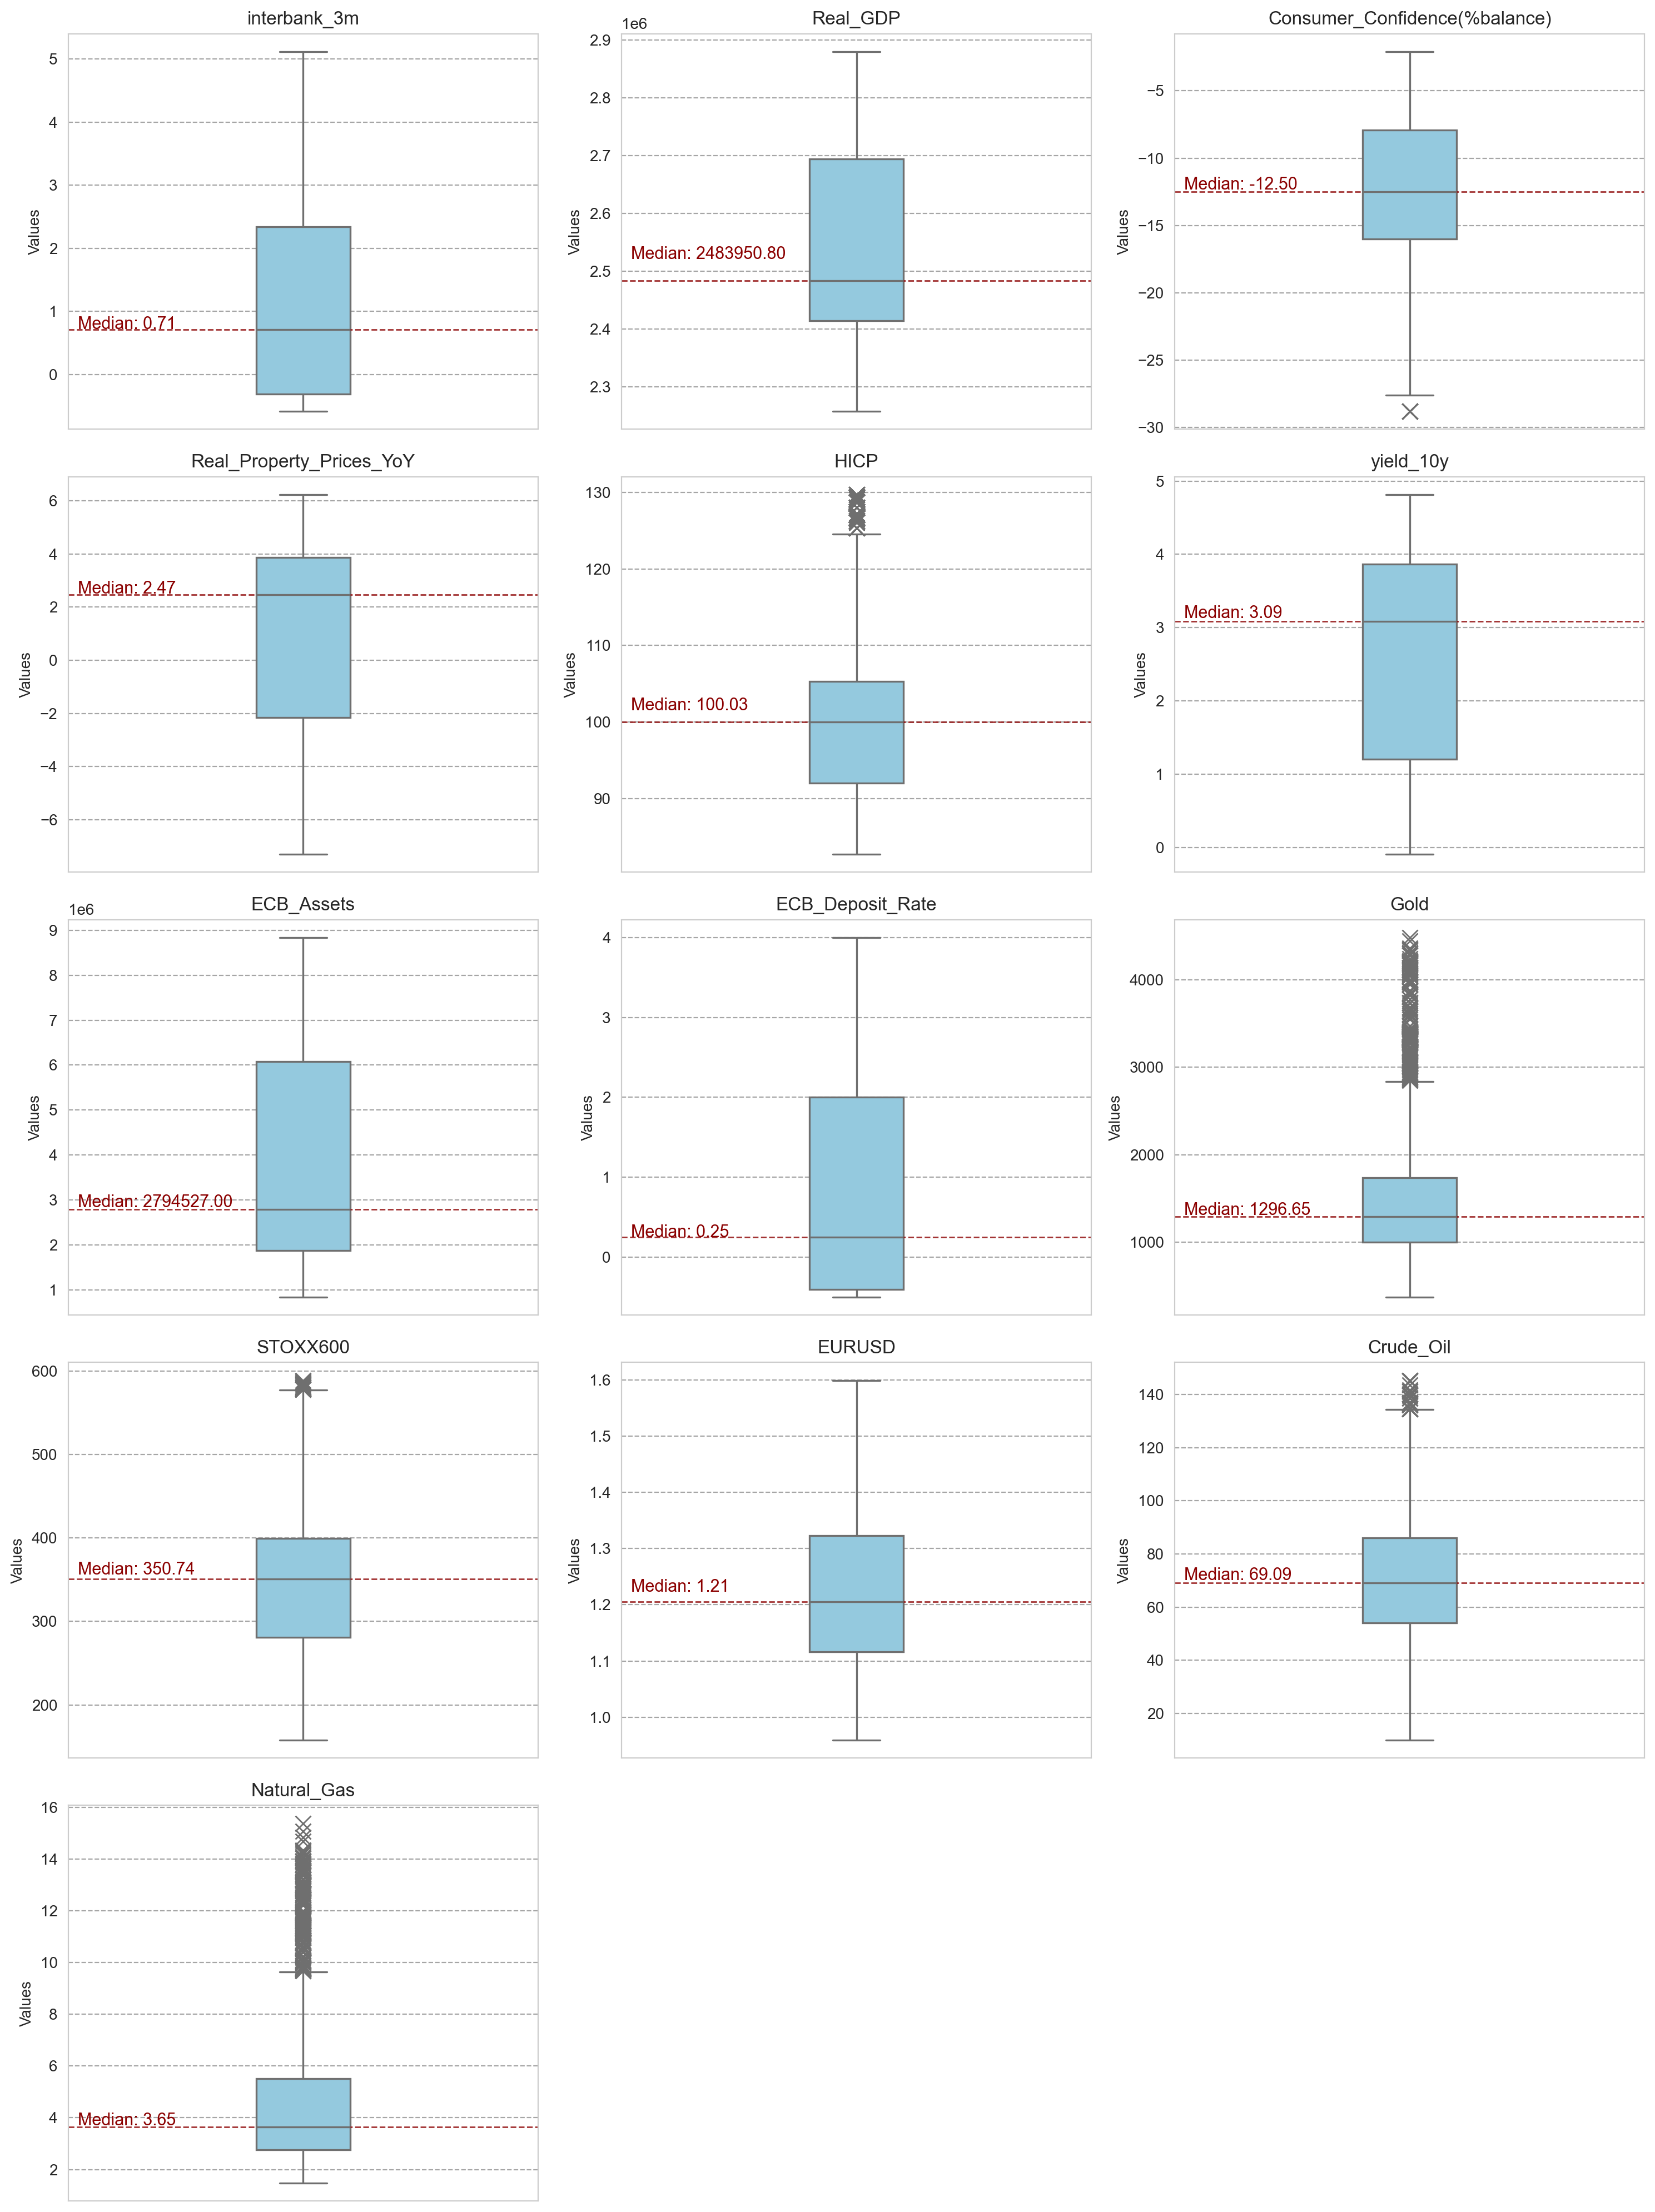

In [6]:
fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    sns.boxplot(
    data = df_raw[col],
    ax = axes[i],
    color = 'skyblue',
    width = 0.2,
    linewidth = 1.2,
    whis = 1.5,
    flierprops=dict(marker='x', color='black', markersize=10)
    )
    
    median = df_raw[col].median()
    axes[i].axhline(
        median,
        color='darkred',
        linestyle='--',
        linewidth=1,
        alpha=0.8
    )
    axes[i].annotate(
        f'Median: {median:.2f}',
        xy=(0.02, median + (0.015 * abs(median))),
        xycoords=('axes fraction', 'data'),
        fontsize=11,
        color='darkred'
    )
    
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Values')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 6. Correlation Analysis

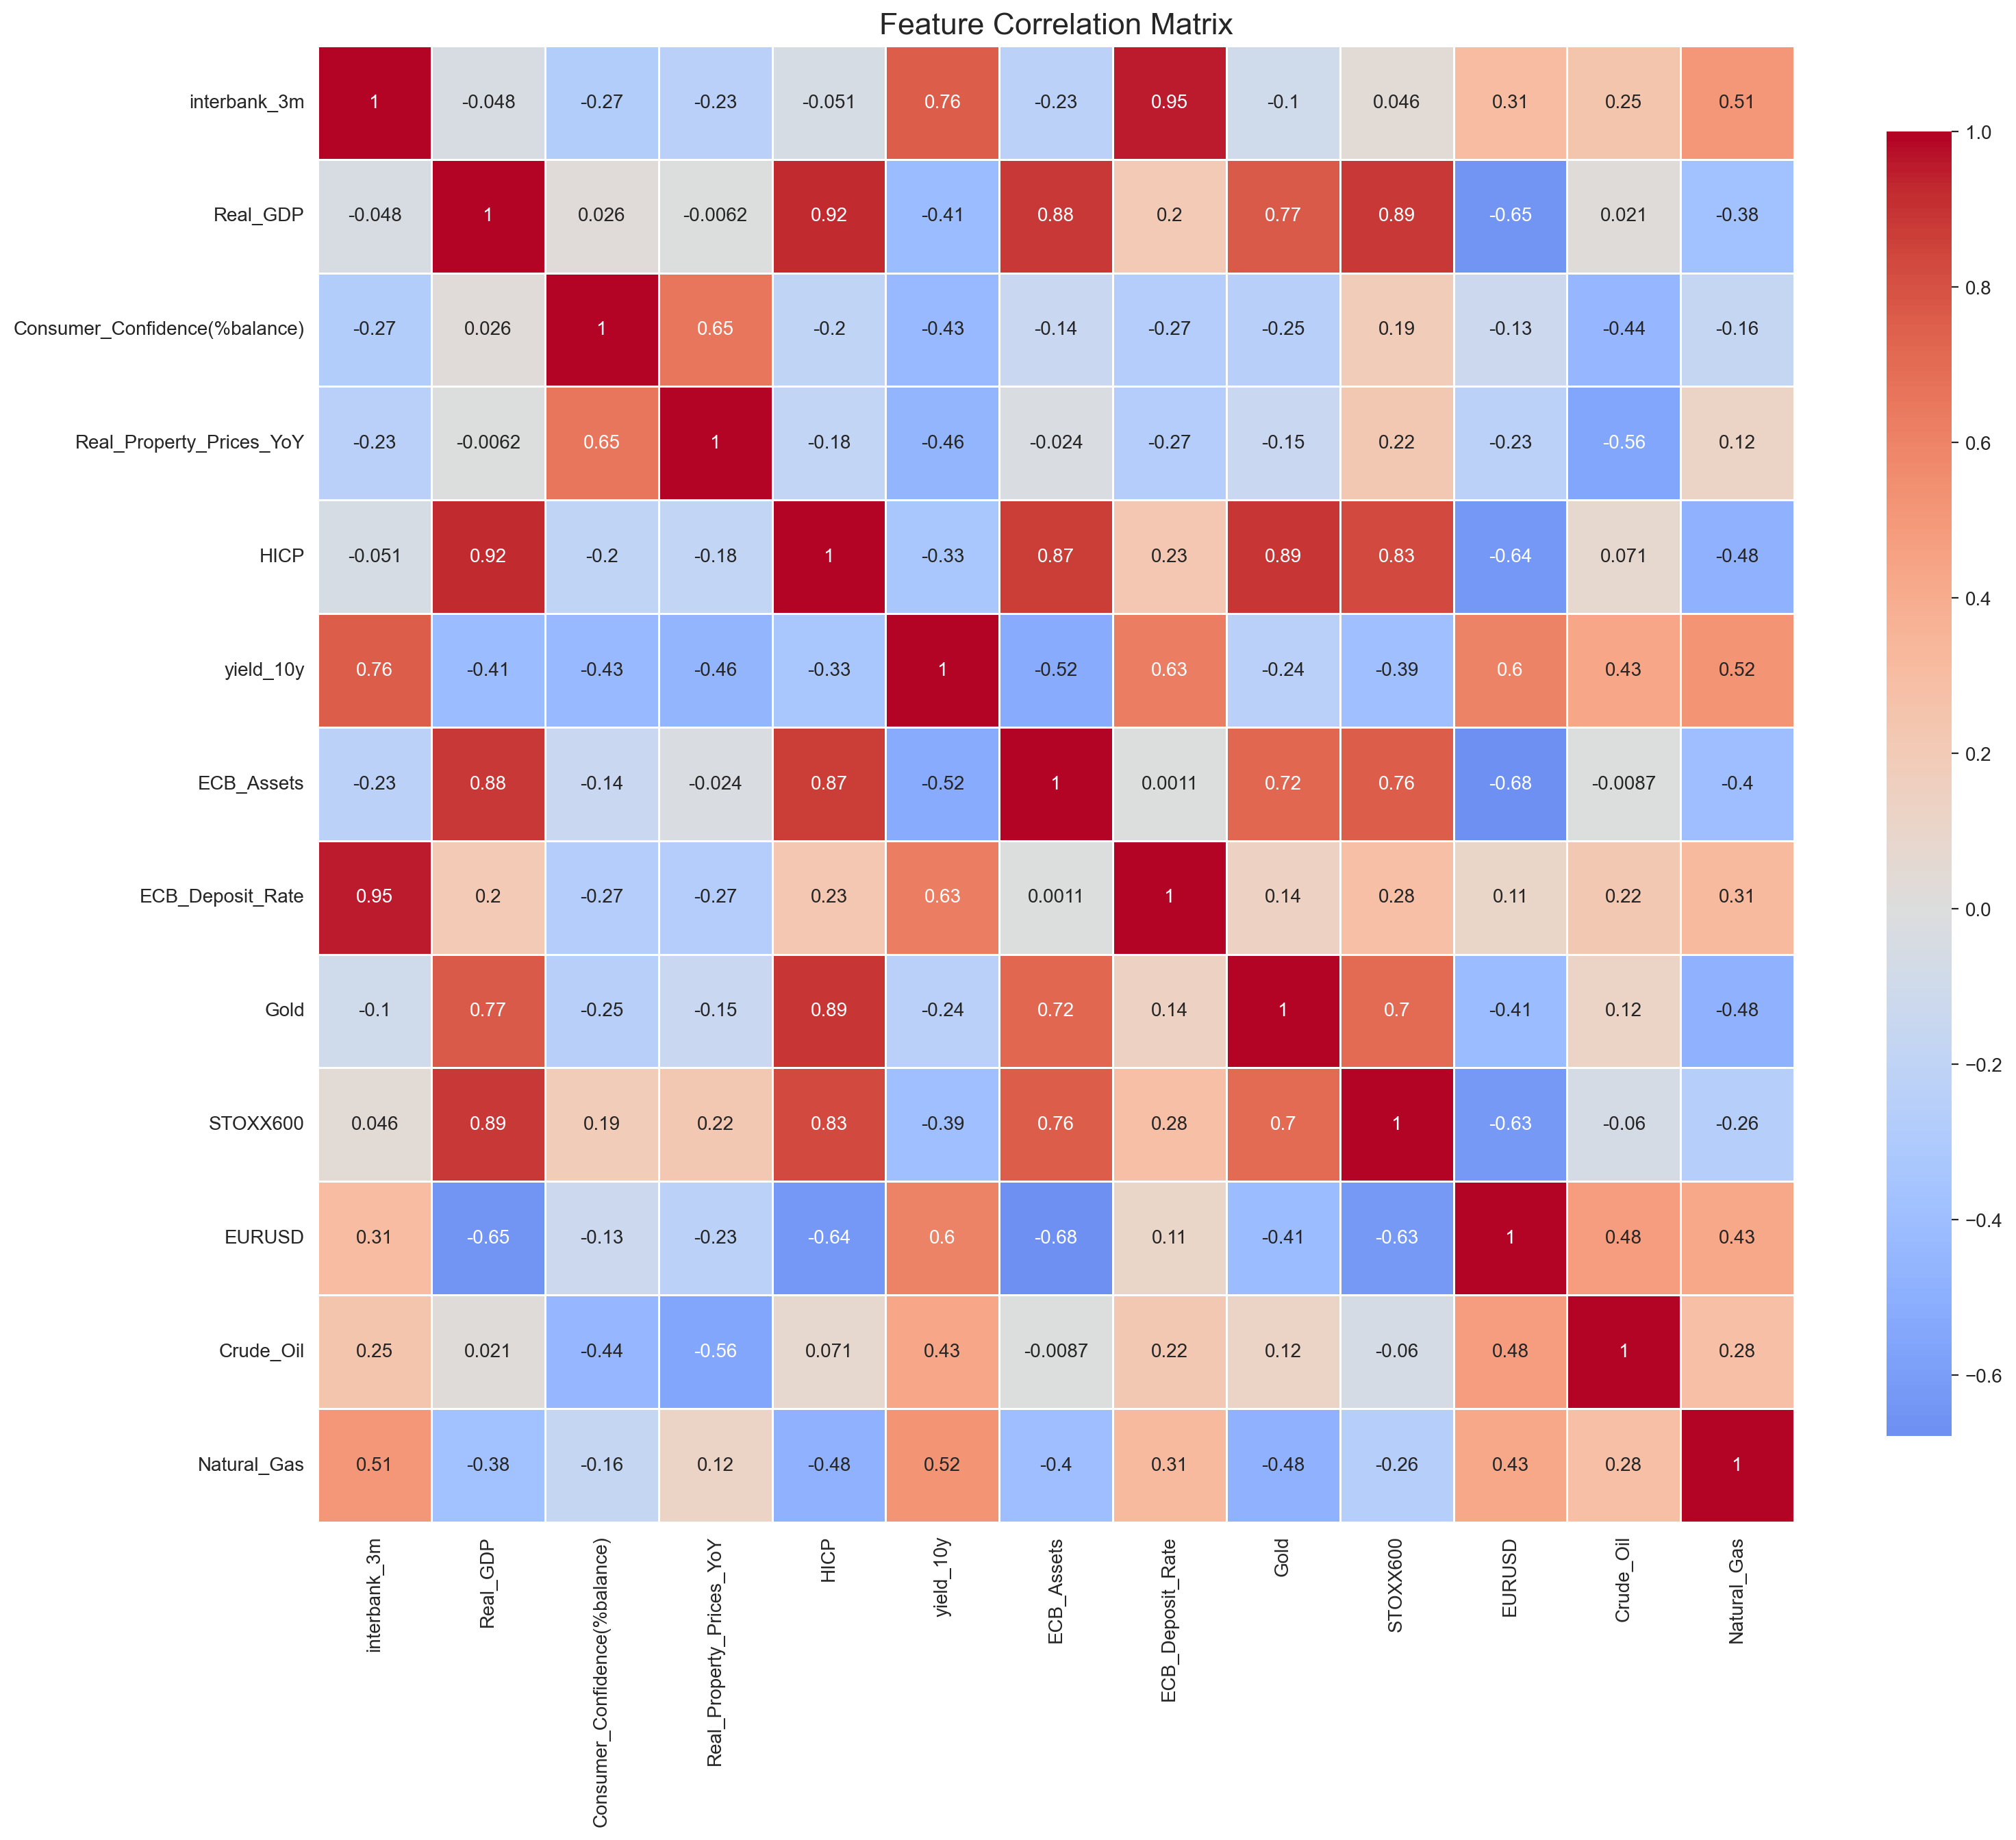

In [7]:
corr_matrix = df_raw[numeric_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm', center = 0,
            square = True, linewidths = 0.5, cbar_kws = {"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

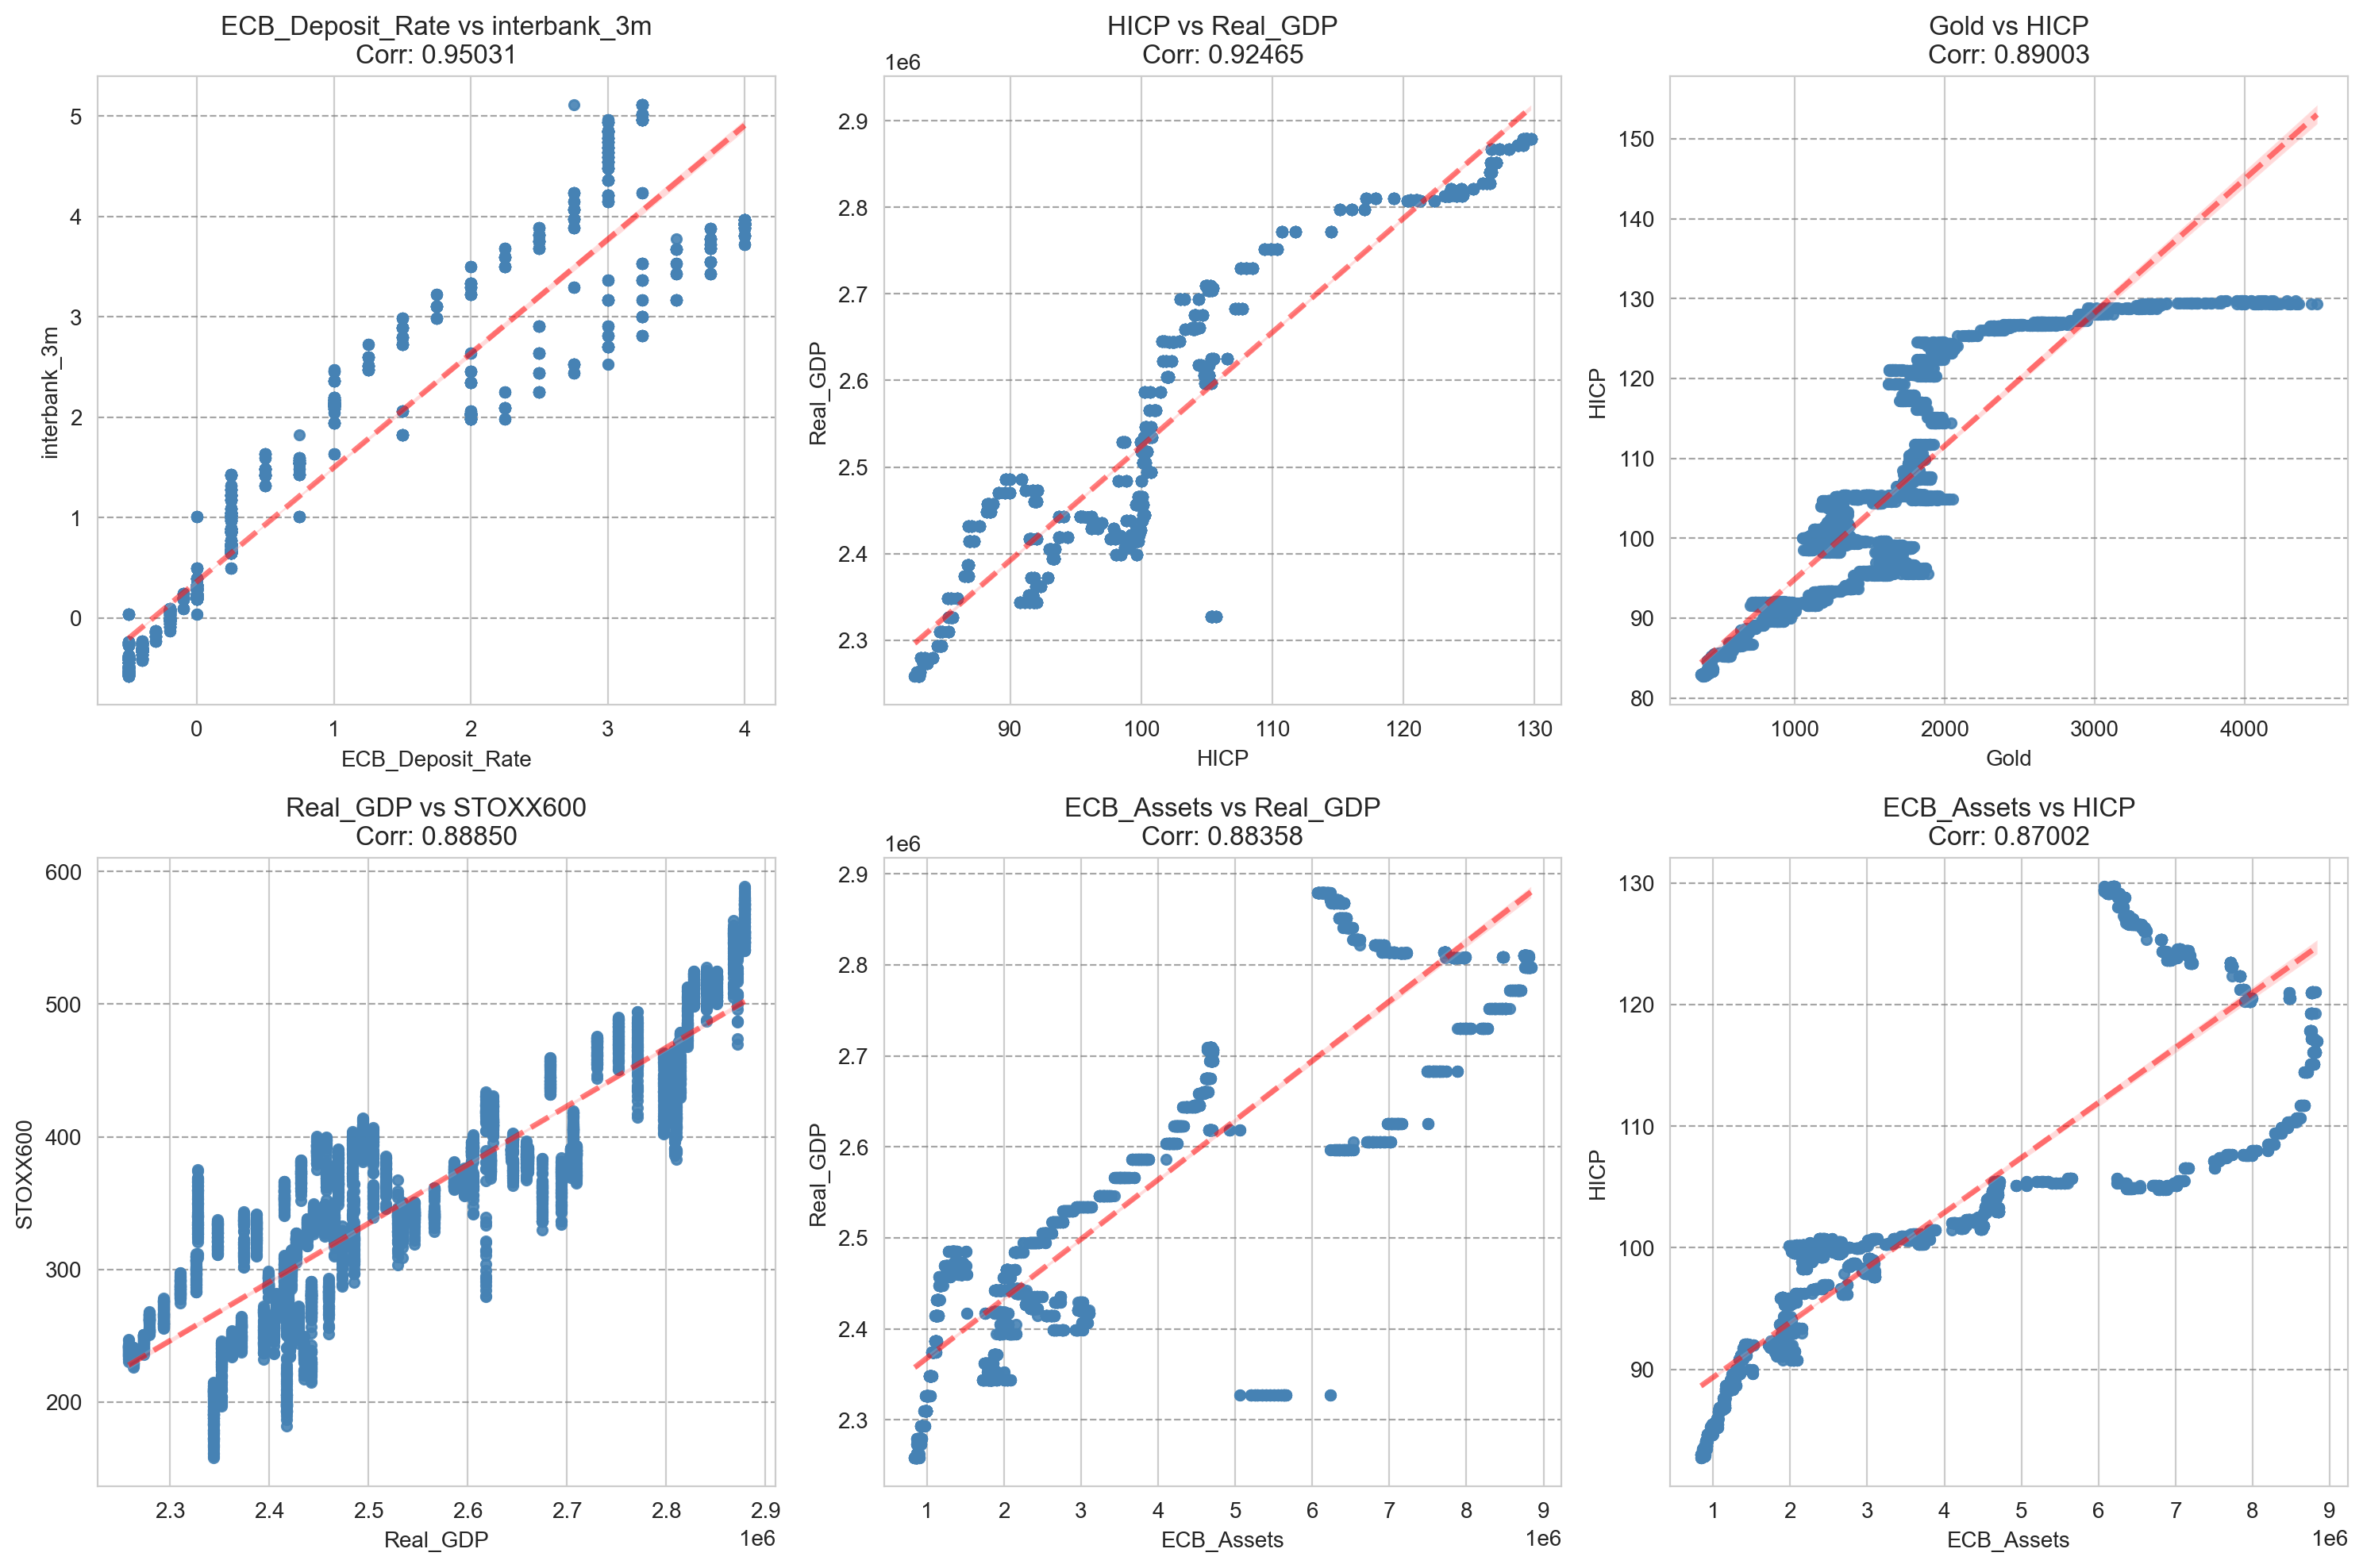

In [8]:
corr_signed = corr_matrix.unstack()
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.groupby(lambda x: tuple(sorted(x))).first().sort_values(ascending = False)
top_pairs = corr_pairs.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ((var1, var2), _) in enumerate(top_pairs.items()):
    corr_val = corr_signed.loc[(var1, var2)]
    sns.regplot(
        data = df_raw,
        x = var1,
        y = var2,
        ax = axes[i],
        scatter = True,
        color = 'red',
        line_kws={"linewidth": 2.5, "linestyle": "--", 'alpha': 0.5},
        scatter_kws={'color': 'steelblue', 'alpha': 0.9, 's': 20},
)
    axes[i].set_title(f'{var1} vs {var2}\nCorr: {corr_val:.5f}')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

#### 7. Time series overview for all indicators

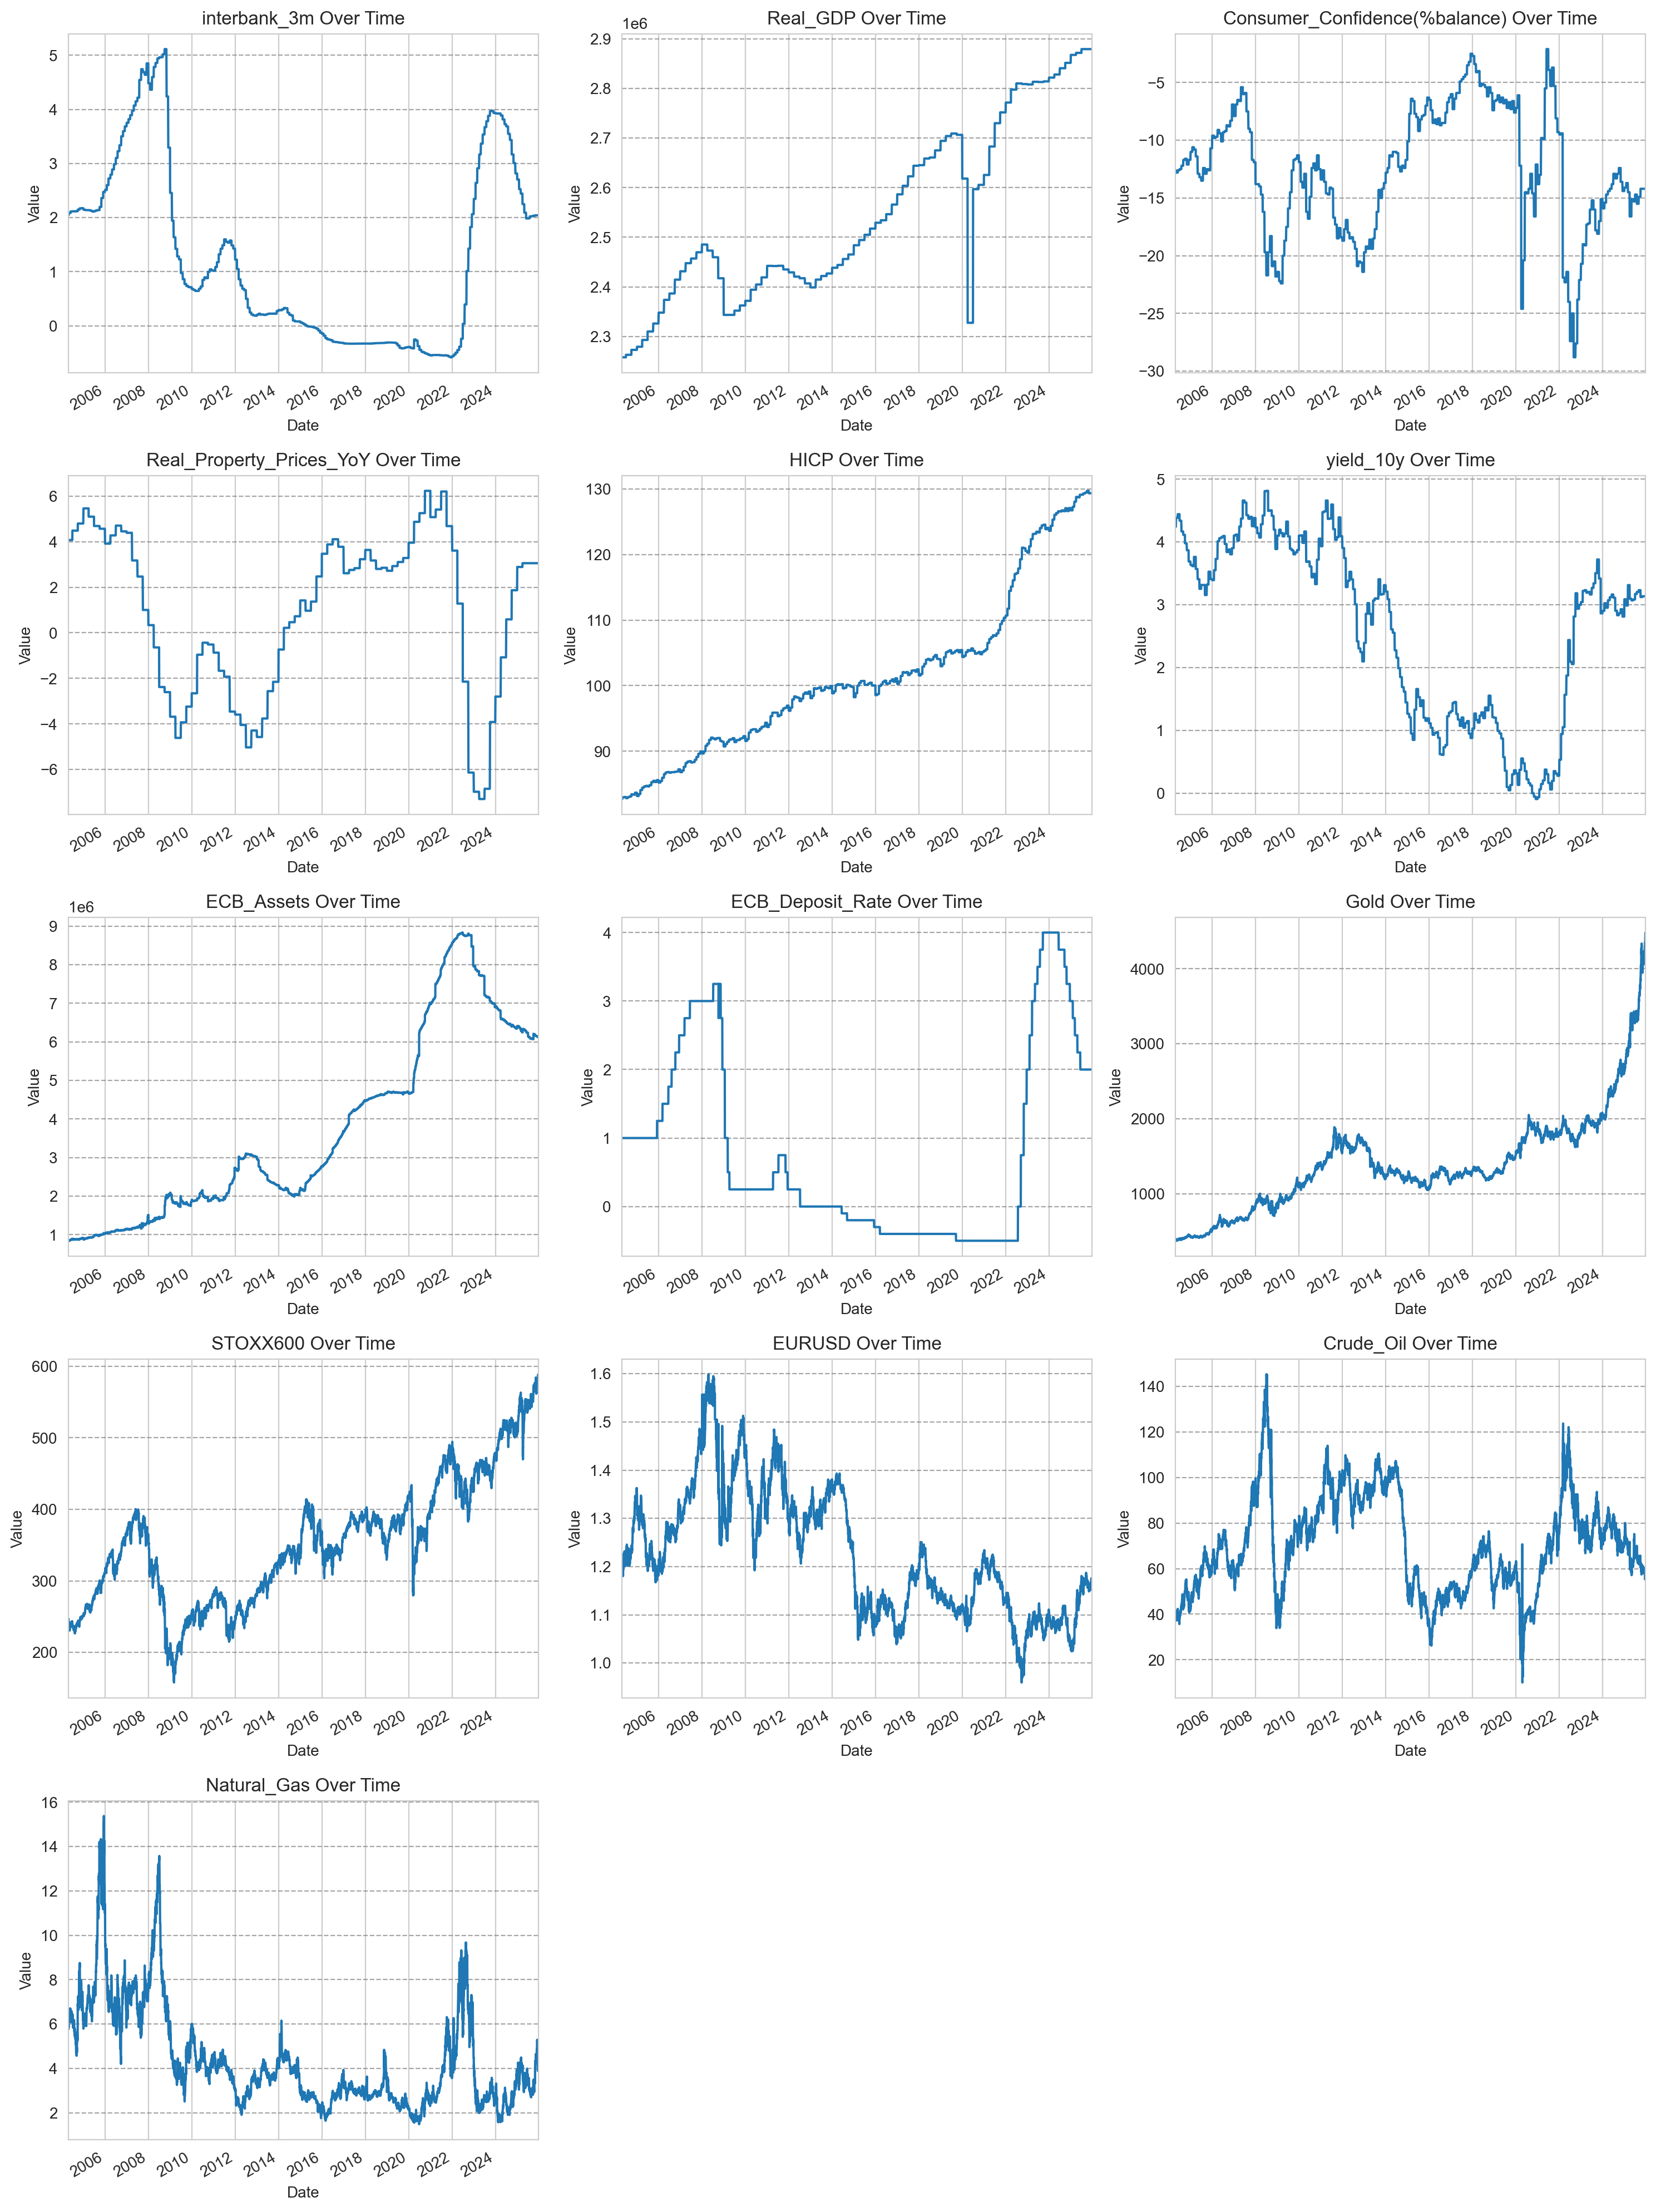

In [9]:
fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    df_raw.plot(x = 'date', y = col, ax = axes[i], title = f'{col} Over Time')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    axes[i].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=15))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].set_xlim(df_raw['date'].min(), df_raw['date'].max())
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)
    axes[i].get_legend().remove()


for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 8. Feature Engineering

In [10]:
df_engineered = loader.engineer_all_features(df = df_raw_offset.copy())

print(f"Engineered dataset shape: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df_raw_offset.shape[1]}")

# Display sample of new features
new_features = [col for col in df_engineered.columns if col not in df_raw_offset.columns]
df_engineered[['date'] + new_features[:10]].head()

Engineered dataset shape: (4363, 127)
New features created: 113


,date,Natural_Gas_ret_1d,Natural_Gas_ret_5d,Natural_Gas_ret_10d,Natural_Gas_ret_21d,Natural_Gas_ret_63d,Natural_Gas_ret_126d,Natural_Gas_ret_252d,Natural_Gas_vol_5d,Natural_Gas_vol_21d,Natural_Gas_vol_63d
1287,2009-04-01,-0.021451,-0.146454,0.002986,-0.137086,-0.381176,-0.454048,-0.632448,0.052755,0.046427,0.034020
1288,2009-04-02,0.023545,-0.041804,-0.093915,-0.128571,-0.377141,-0.439039,-0.629397,0.045036,0.046688,0.034105
1289,2009-04-03,0.005024,0.046819,-0.100781,-0.070205,-0.364700,-0.443077,-0.635675,0.019907,0.045141,0.034123
1290,2009-04-06,-0.018153,-0.001872,-0.130880,-0.053992,-0.364441,-0.428921,-0.640566,0.019151,0.044683,0.034121
1291,2009-04-07,-0.045552,-0.056674,-0.180584,-0.078396,-0.361992,-0.467404,-0.663550,0.026476,0.045541,0.034050


#### 9. Save Processed Data (Optional)

In [11]:
df_engineered.to_csv('../data/master_dataset_eurozone.csv', index=False)